2026-08-11 16:04:40.240235: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/jihyoyue/anaconda3/envs/Jihyo_AI/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
I0000 00:00:1786439085.686210     591 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-08-11 16:05:25.172046: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f7b1c0fb470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-11 16:0

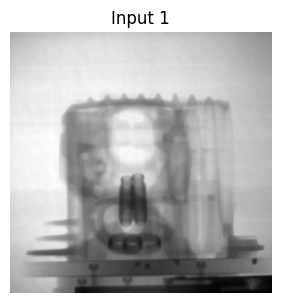

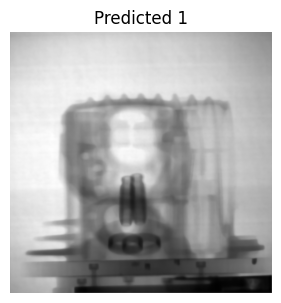

In [1]:
# ========================================================================== #
# = Neutron Tomography - Data Interpolation                                = #
# = Authors :   - Nur bayyinah (Jember University)                         = #
# =             - Fahrurrozi Akbar (BRIN)                                  = #
# =             - Ratna Dewi Syarifah (Jember University)                  = #
# =             - Bharoto (BRIN)                                           = #
# =             - Andeka Tris Susanto (BRIN)                               = #
# =             - Khairul Handono (BRIN)                                   = #
# =             - Fitri Surya Ningsih (BRIN)                               = #
# ========================================================================== #

# Licence:                                                                   #
# The National Research And Innovation Agency - BRIN                         #
# Jember University                                                          #
# Coresponding Author : - nurbayina020@gmail.com                             #
#                        - fahrurrozi.akbar2@gmail.com                       #
# ========================================================================== #

# Libraries : 
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from glob import glob
from PIL import Image, ImageTk
import tifffile
import tkinter as tk
from tkinter import ttk, filedialog, messagebox, scrolledtext
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import threading
import logging
##from tkinter import font
import io
import sys


# Keras Register - Custom 
# ==========================================================================
@tf.keras.utils.register_keras_serializable(package="Custom")
class TimeMean(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=1)

@tf.keras.utils.register_keras_serializable(package="Custom")
class TimeLast(tf.keras.layers.Layer):
    def call(self, inputs):
        return inputs[:, -1, :, :, :]

@tf.keras.utils.register_keras_serializable(package="Custom")
class SkipFusion(tf.keras.layers.Layer):
    def __init__(self, filters=64, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.conv = tf.keras.layers.Conv2D(filters, (1, 1), padding='same', activation='relu')

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=1)
        last = inputs[:, -1, :, :, :]
        fused = tf.concat([mean, last], axis=-1)
        return self.conv(fused)

    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters})
        return config


custom_objects = {
    "SkipFusion": SkipFusion,
    "TimeMean": TimeMean,
    "TimeLast": TimeLast
}

# =========================================================================
class ImagePredictionGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("X-Ray and Neutron CT - Interpolation - 2 to 1")
        self.root.geometry("1200x800")

        # Initialize variables
        self.input_folder = ""
        self.output_folder = "Data/Out_Data_Prediction"
        self.generator = None
        self.input_images = []
        self.predicted_images = []
        self.current_input_index = 0
        self.current_pred_index = 0
        self.logo_image = None
        self.logo_photo = None

        # Store raw data for saving
        self.predicted_images_raw = []  # Store denormalized predictions

        # Setup logging
        self.setup_logging()

        # Create GUI
        self.create_widgets()

        # Load model in background
        self.load_model()

        # Load logo
        self.load_logo()

    def load_logo(self):
        """Load and resize BRIN logo"""
        try:
            logo_path = "Images/BRIN.png"   #Foto/BRIN.png
            if os.path.exists(logo_path):
                # Load and resize logo
                logo = Image.open(logo_path)
                
                # Resize logo to appropriate size (adjust as needed)
                logo_width = 60   # 150 Default
                logo_height = int(logo.height * (logo_width / logo.width))
                logo = logo.resize((logo_width, logo_height), Image.Resampling.LANCZOS)
                
                # Convert to PhotoImage
                self.logo_photo = ImageTk.PhotoImage(logo)
                self.logo_image = logo
                
                # Update header if already created
                if hasattr(self, 'header_frame'):
                    self.update_header()
            else:
                print(f"Logo not found at {logo_path}")
        except Exception as e:
            print(f"Error loading logo: {str(e)}")

    def update_header(self):
        """Update header with logo and text"""
        # Clear existing header content
        for widget in self.header_frame.winfo_children():
            widget.destroy()

        # Create left frame for logo
        logo_frame = ttk.Frame(self.header_frame)
        logo_frame.pack(side=tk.LEFT, padx=(0, 10))

        if self.logo_photo:
            # Display logo
            logo_label = ttk.Label(logo_frame, image=self.logo_photo)
            logo_label.pack()
        else:
            # Placeholder if logo not loaded
            placeholder = ttk.Label(logo_frame, text="[BRIN Logo]", font=("Arial", 10))
            placeholder.pack()

        # Create right frame for title text
        text_frame = ttk.Frame(self.header_frame)
        text_frame.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)

        # Main title
        title_label = ttk.Label(text_frame, text="DL for Neutron/X-Ray CT",
                                font=("Arial", 120, "bold"), foreground="#2c3e50") #120 default
        title_label.pack(anchor=tk.W, pady=(10, 0))  #5, 0

        # Subtitle
        subtitle_label = ttk.Label(text_frame, text="Deep Learning Interpolation Tool",
                                   font=("Arial", 40), foreground="#7f8c8d")
        subtitle_label.pack(anchor=tk.W)

    def setup_logging(self):
        """Setup logging to capture all output"""
        self.log_stream = io.StringIO()
        handler = logging.StreamHandler(self.log_stream)
        handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))

        self.logger = logging.getLogger()
        self.logger.setLevel(logging.INFO)
        self.logger.addHandler(handler)

        # Redirect stdout and stderr
        self.old_stdout = sys.stdout
        self.old_stderr = sys.stderr
        sys.stdout = self.log_stream
        sys.stderr = self.log_stream

    def create_widgets(self):
        # Main frame
        main_frame = ttk.Frame(self.root, padding="10")
        main_frame.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))

        # Configure grid weights
        self.root.columnconfigure(0, weight=1)
        self.root.rowconfigure(0, weight=1)
        main_frame.columnconfigure(1, weight=1)

        # Header frame with logo and title
        self.header_frame = ttk.Frame(main_frame)
        self.header_frame.grid(row=0, column=0, columnspan=3, sticky=(tk.W, tk.E), pady=(0, 20))
        
        # Initialize header
        self.update_header()

        # Folder selection frame
        folder_frame = ttk.LabelFrame(main_frame, text="Folder Selection", padding="10")
        folder_frame.grid(row=1, column=0, columnspan=3, sticky=(tk.W, tk.E), pady=(0, 10))
        folder_frame.columnconfigure(1, weight=1)

        # Input folder
        ttk.Label(folder_frame, text="Input Folder:").grid(row=0, column=0, sticky=tk.W, pady=2)
        self.input_folder_var = tk.StringVar()
        ttk.Entry(folder_frame, textvariable=self.input_folder_var, state='readonly').grid(row=0, column=1,
                                                                                           sticky=(tk.W, tk.E),
                                                                                           padx=(5, 5), pady=2)
        ttk.Button(folder_frame, text="Browse", command=self.browse_input_folder).grid(row=0, column=2, pady=2)

        # Output folder
        ttk.Label(folder_frame, text="Output Folder:").grid(row=1, column=0, sticky=tk.W, pady=2)
        self.output_folder_var = tk.StringVar(value=self.output_folder)
        ttk.Entry(folder_frame, textvariable=self.output_folder_var, state='readonly').grid(row=1, column=1,
                                                                                            sticky=(tk.W, tk.E),
                                                                                            padx=(5, 5), pady=2)

        # Control buttons frame
        control_frame = ttk.Frame(main_frame)
        control_frame.grid(row=2, column=0, columnspan=3, pady=(10, 10))

        ttk.Button(control_frame, text="Load Images", command=self.load_images).pack(side=tk.LEFT, padx=5)
        ttk.Button(control_frame, text="Start Prediction", command=self.start_prediction).pack(side=tk.LEFT, padx=5)
        ttk.Button(control_frame, text="Save Results", command=self.save_results).pack(side=tk.LEFT, padx=5)
        ttk.Button(control_frame, text="Clear Log", command=self.clear_log).pack(side=tk.LEFT, padx=5)

        # Image display frame
        image_frame = ttk.LabelFrame(main_frame, text="Image Display", padding="10")
        image_frame.grid(row=3, column=0, columnspan=3, sticky=(tk.W, tk.E, tk.N, tk.S), pady=(0, 10))
        main_frame.rowconfigure(3, weight=1)
        image_frame.columnconfigure(0, weight=1)
        image_frame.columnconfigure(1, weight=1)
        image_frame.rowconfigure(0, weight=1)

        # Input images frame
        input_frame = ttk.Frame(image_frame)
        input_frame.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S), padx=(0, 10))
        input_frame.columnconfigure(0, weight=1)
        input_frame.rowconfigure(1, weight=1)

        ttk.Label(input_frame, text="Input Images", font=("Arial", 12, "bold")).grid(row=0, column=0, pady=(0, 10))
        self.input_canvas_frame = ttk.Frame(input_frame)
        self.input_canvas_frame.grid(row=1, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))
        self.input_canvas_frame.columnconfigure(0, weight=1)
        self.input_canvas_frame.rowconfigure(0, weight=1)

        # Input scrollbar
        input_scroll_frame = ttk.Frame(input_frame)
        input_scroll_frame.grid(row=2, column=0, sticky=(tk.W, tk.E), pady=(10, 0))
        ttk.Label(input_scroll_frame, text="Image:").pack(side=tk.LEFT)
        self.input_scroll = ttk.Scale(input_scroll_frame, from_=0, to=0, orient=tk.HORIZONTAL,
                                      command=self.on_input_scroll)
        self.input_scroll.pack(side=tk.LEFT, fill=tk.X, expand=True)
        self.input_index_label = ttk.Label(input_scroll_frame, text="0/0")
        self.input_index_label.pack(side=tk.RIGHT, padx=(5, 0))

        # Predicted images frame
        pred_frame = ttk.Frame(image_frame)
        pred_frame.grid(row=0, column=1, sticky=(tk.W, tk.E, tk.N, tk.S), padx=(10, 0))
        pred_frame.columnconfigure(0, weight=1)
        pred_frame.rowconfigure(1, weight=1)

        ttk.Label(pred_frame, text="Predicted Images", font=("Arial", 12, "bold")).grid(row=0, column=0, pady=(0, 10))
        self.pred_canvas_frame = ttk.Frame(pred_frame)
        self.pred_canvas_frame.grid(row=1, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))
        self.pred_canvas_frame.columnconfigure(0, weight=1)
        self.pred_canvas_frame.rowconfigure(0, weight=1)

        # Prediction scrollbar
        pred_scroll_frame = ttk.Frame(pred_frame)
        pred_scroll_frame.grid(row=2, column=0, sticky=(tk.W, tk.E), pady=(10, 0))
        ttk.Label(pred_scroll_frame, text="Image:").pack(side=tk.LEFT)
        self.pred_scroll = ttk.Scale(pred_scroll_frame, from_=0, to=0, orient=tk.HORIZONTAL,
                                     command=self.on_pred_scroll)
        self.pred_scroll.pack(side=tk.LEFT, fill=tk.X, expand=True)
        self.pred_index_label = ttk.Label(pred_scroll_frame, text="0/0")
        self.pred_index_label.pack(side=tk.RIGHT, padx=(5, 0))

        # Log frame
        log_frame = ttk.LabelFrame(main_frame, text="Log Output", padding="10")
        log_frame.grid(row=4, column=0, columnspan=3, sticky=(tk.W, tk.E, tk.N, tk.S), pady=(0, 10))
        log_frame.columnconfigure(0, weight=1)
        log_frame.rowconfigure(0, weight=1)
        main_frame.rowconfigure(4, weight=1)

        self.log_text = scrolledtext.ScrolledText(log_frame, height=8, width=100)
        self.log_text.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))

        # Status bar
        self.status_var = tk.StringVar(value="Ready")
        status_bar = ttk.Label(main_frame, textvariable=self.status_var, relief=tk.SUNKEN)
        status_bar.grid(row=5, column=0, columnspan=3, sticky=(tk.W, tk.E), pady=(5, 0))

        # Initialize matplotlib figures
        self.setup_matplotlib_figures()

        self.clear_all_images()

    def setup_matplotlib_figures(self):
        """Initialize all matplotlib figures and canvases"""
        # Input figure
        self.input_fig, self.input_ax = plt.subplots(figsize=(4, 4))
        self.input_canvas = FigureCanvasTkAgg(self.input_fig, self.input_canvas_frame)
        self.input_canvas.get_tk_widget().grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))

        # Prediction figure
        self.pred_fig, self.pred_ax = plt.subplots(figsize=(4, 4))
        self.pred_canvas = FigureCanvasTkAgg(self.pred_fig, self.pred_canvas_frame)
        self.pred_canvas.get_tk_widget().grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))

    def browse_input_folder(self):
        folder = filedialog.askdirectory(title="Select Input Folder")
        if folder:
            self.input_folder = folder
            self.input_folder_var.set(folder)
            self.log_message(f"Input folder set to: {folder}")

    def load_model(self):
        """Load the model in a separate thread"""

        def load_model_thread():
            try:
                self.log_message("Loading model...")
                # This is Auto load, Change this location if needed
                model_path = "Save_Model/generator(Salinan 3 Ginet TC-D_Revisi).h5"
                if not os.path.exists(model_path):
                    self.log_message(f"ERROR: Model file not found at {model_path}")
                    return

                self.generator = tf.keras.models.load_model(
                    model_path, custom_objects=custom_objects, compile=False
                )
                self.log_message("✅ Model loaded successfully!")
                self.status_var.set("Model loaded successfully")
            except Exception as e:
                error_msg = f"ERROR loading model: {str(e)}"
                self.log_message(error_msg)
                self.status_var.set("Error loading model")

        threading.Thread(target=load_model_thread, daemon=True).start()

    def load_images(self):
        """Load images from selected folders"""
        if not self.input_folder:
            messagebox.showerror("Error", "Please select input folder")
            return

        def load_images_thread():
            try:
                self.status_var.set("Loading images...")
                self.log_message("Loading input images...")
                self.input_images = self.load_tif_folder_sorted(self.input_folder)
                self.log_message(f"Loaded {len(self.input_images)} input images")

                # Update scrollbars
                self.input_scroll.config(from_=0, to=max(0, len(self.input_images) - 1))

                # Update labels
                self.input_index_label.config(text=f"0/{len(self.input_images)}")

                # Display first image
                if self.input_images:
                    self.display_input_image(0)

                self.status_var.set("Images loaded successfully")
                self.log_message("✅ All images loaded successfully!")

            except Exception as e:
                error_msg = f"ERROR loading images: {str(e)}"
                self.log_message(error_msg)
                self.status_var.set("Error loading images")

        threading.Thread(target=load_images_thread, daemon=True).start()

    def load_tif_folder_sorted(self, folder, target_size=(1024, 1024)):
        """Load and sort TIFF images from folder"""
        paths = sorted(glob(os.path.join(folder, "*.tif")))
        images = []
        for p in paths:
            try:
                img = Image.open(p).convert("I")
                img = img.resize(target_size[::-1])
                img = np.array(img, dtype=np.float32)
                images.append(img)
            except Exception as e:
                self.log_message(f"Error loading {p}: {str(e)}")

        return images

    def start_prediction(self):
        """Start the prediction process"""
        if not self.generator:
            messagebox.showerror("Error", "Model not loaded yet")
            return

        if not self.input_images:
            messagebox.showerror("Error", "Please load images first")
            return

        def prediction_thread():
            try:
                self.status_var.set("Running prediction...")
                self.log_message("Starting prediction...")

                # Run prediction function
                self.generate_predictions()

                # Update prediction scrollbar
                self.pred_scroll.config(from_=0, to=max(0, len(self.predicted_images) - 1))

                # Update label
                self.pred_index_label.config(text=f"0/{len(self.predicted_images)}")

                # Display first predicted image
                if self.predicted_images:
                    self.display_predicted_image(0)

                self.status_var.set("Prediction completed")
                self.log_message("✅ Prediction completed successfully!")
                self.log_message(f"Total predictions generated: {len(self.predicted_images)}")

            except Exception as e:
                error_msg = f"ERROR during prediction: {str(e)}"
                self.log_message(error_msg)
                self.status_var.set("Error during prediction")

        threading.Thread(target=prediction_thread, daemon=True).start()

    def generate_predictions(self):
        """Generate predictions from input images"""
        os.makedirs(self.output_folder, exist_ok=True)

        GLOBAL_MIN = 0.0
        GLOBAL_MAX = 65535.0

        # Convert loaded images to the format your function expects
        input_seq = np.stack(self.input_images, axis=0)
        input_seq = np.expand_dims(input_seq, axis=-1)

        # Clear previous results
        self.predicted_images = []
        self.predicted_images_raw = []

        # Resize and normalize
        input_seq = tf.image.resize(input_seq, (1024, 1024)).numpy()
        input_seq = 2.0 * (input_seq - GLOBAL_MIN) / (GLOBAL_MAX - GLOBAL_MIN) - 1.0

        n = len(input_seq) - 1  # Number of predictions we can generate

        self.log_message(f"Generating {n} predictions from {len(input_seq)} input images...")

        for i in range(n):
            t0 = input_seq[i]
            t2 = input_seq[i + 1]

            input_pair = np.stack([t0, t2], axis=0)[np.newaxis, ...]
            time_scalar = np.array([[0.5]], dtype=np.float32)

            pred = self.generator.predict([input_pair, time_scalar], verbose=0)[0, :, :, 0]

            pred_denorm = (pred + 1.0) / 2.0 * (GLOBAL_MAX - GLOBAL_MIN) + GLOBAL_MIN

            # Store denormalized images
            self.predicted_images_raw.append(pred_denorm)

            # Save prediction as TIFF
            save_path = os.path.join(self.output_folder, f"pred_{2 * i + 1:04d}.tif")
            pred_16bit = np.clip(pred_denorm, 0, 65535).astype(np.uint16)
            tifffile.imwrite(save_path, pred_16bit)

            # Store normalized version for display
            pred_normalized = (pred_denorm - GLOBAL_MIN) / (GLOBAL_MAX - GLOBAL_MIN)
            self.predicted_images.append(pred_normalized)

            if (i + 1) % 10 == 0:  # Log progress every 10 images
                self.log_message(f"Generated {i + 1}/{n} predictions...")

            self.log_message(f"Generated prediction {2 * i + 1:03d}")

        self.log_message(f"\nAll predictions saved to: {self.output_folder}")

    def display_input_image(self, index):
        """Display input image at given index"""
        if 0 <= index < len(self.input_images):
            self.input_ax.clear()
            # Normalize for display
            img_normalized = (self.input_images[index] - np.min(self.input_images[index])) / (
                        np.max(self.input_images[index]) - np.min(self.input_images[index]))
            self.input_ax.imshow(img_normalized, cmap='gray')
            self.input_ax.set_title(f'Input {index + 1}')
            self.input_ax.axis('off')
            self.input_canvas.draw()
            self.current_input_index = index
            self.input_index_label.config(text=f"{index + 1}/{len(self.input_images)}")

    def display_predicted_image(self, index):
        """Display predicted image at given index"""
        if 0 <= index < len(self.predicted_images):
            self.pred_ax.clear()
            self.pred_ax.imshow(self.predicted_images[index], cmap='gray')
            self.pred_ax.set_title(f'Predicted {index + 1}')
            self.pred_ax.axis('off')
            self.pred_canvas.draw()
            self.current_pred_index = index
            self.pred_index_label.config(text=f"{index + 1}/{len(self.predicted_images)}")

    def on_input_scroll(self, value):
        index = int(float(value))
        self.display_input_image(index)

    def on_pred_scroll(self, value):
        index = int(float(value))
        self.display_predicted_image(index)

    def save_results(self):
        """Save current results"""
        if not self.predicted_images_raw:
            messagebox.showwarning("Warning", "No prediction results to save")
            return

        try:
            save_folder = filedialog.askdirectory(title="Select folder to save results")
            if save_folder:
                # Save ALL prediction images
                self.log_message(f"Saving all {len(self.predicted_images_raw)} prediction images...")

                for i, pred_img in enumerate(self.predicted_images_raw):
                    # Save as TIFF
                    pred_path = os.path.join(save_folder, f"prediction_{i + 1:04d}.tif")
                    pred_16bit = np.clip(pred_img, 0, 65535).astype(np.uint16)
                    tifffile.imwrite(pred_path, pred_16bit)

                # Save currently displayed images as PNG for quick viewing
                self.save_current_display(save_folder)

                self.log_message(f"✅ All {len(self.predicted_images_raw)} predictions saved to: {save_folder}")
                messagebox.showinfo("Success", f"All {len(self.predicted_images_raw)} predictions saved successfully!")

        except Exception as e:
            error_msg = f"Error saving results: {str(e)}"
            self.log_message(error_msg)
            messagebox.showerror("Error", error_msg)

    def save_current_display(self, save_folder):
        """Save currently displayed images as PNG"""
        # Save input image
        input_path = os.path.join(save_folder, "current_input.png")
        self.input_fig.savefig(input_path, dpi=150, bbox_inches='tight')

        # Save predicted image
        pred_path = os.path.join(save_folder, "current_predicted.png")
        self.pred_fig.savefig(pred_path, dpi=150, bbox_inches='tight')

    def clear_log(self):
        """Clear the log output"""
        self.log_text.delete(1.0, tk.END)

    def log_message(self, message):
        """Add message to log and update display"""
        # Write to log stream
        print(message)

        # Update GUI log in thread-safe manner
        self.root.after(0, self._update_log_display)

    def _update_log_display(self):
        """Update the log display (called in main thread)"""
        log_content = self.log_stream.getvalue()
        self.log_text.delete(1.0, tk.END)
        self.log_text.insert(tk.END, log_content)
        self.log_text.see(tk.END)

    def clear_all_images(self):
        """Clear all image displays"""
        for ax in [self.input_ax, self.pred_ax]:
            ax.clear()
            ax.set_title('No image loaded')
            ax.axis('off')

        self.input_canvas.draw()
        self.pred_canvas.draw()

    def __del__(self):
        """Restore stdout and stderr when object is destroyed"""
        if hasattr(self, 'old_stdout'):
            sys.stdout = self.old_stdout
            sys.stderr = self.old_stderr


def main():
    root = tk.Tk()
    app = ImagePredictionGUI(root)
    root.mainloop()


if __name__ == "__main__":
    main()